# Log Loss - Cross Entropy

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

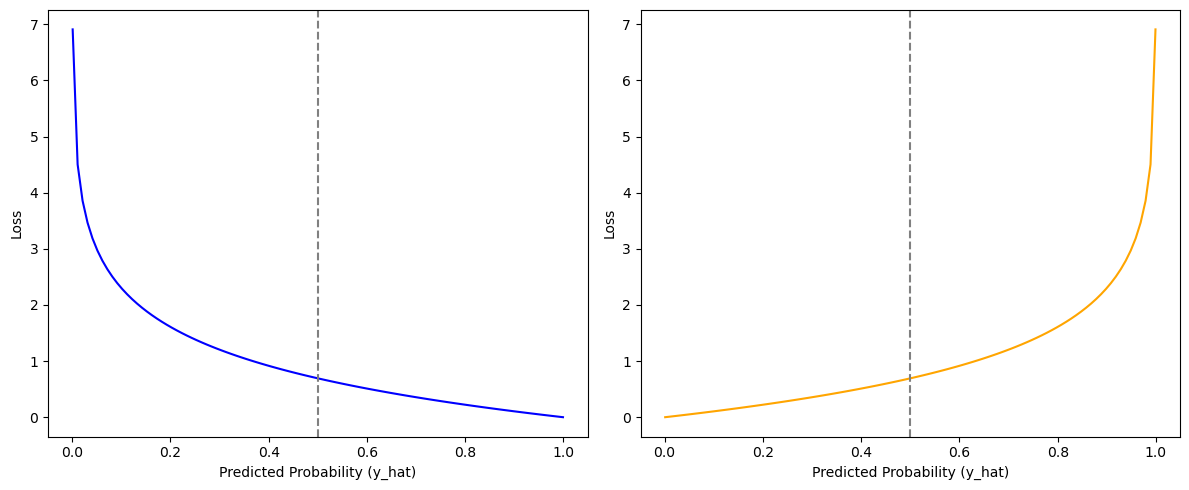

In [2]:
y_hat = np.linspace(0.001, 0.999, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# y_real = 1
axes[0].plot(y_hat, -np.log(y_hat), label='y_real = 1 | -log(y_hat)', color='blue')
axes[0].set_xlabel('Predicted Probability (y_hat)')
axes[0].set_ylabel('Loss')
axes[0].axvline(0.5, color='gray', linestyle='--', label='y_hat = 0.5')

# y_real = 0
axes[1].plot(y_hat, -np.log(1 - y_hat), label='y_real = 0 | -log(1 - y_hat)', color='orange')
axes[1].set_xlabel('Predicted Probability (y_hat)')
axes[1].set_ylabel('Loss')
axes[1].axvline(0.5, color='gray', linestyle='--', label='y_hat = 0.5')

plt.tight_layout()
plt.show()





In [3]:
print("===y_real = 1(has illness) | -log(y_hat) ===")
for y_hat in [0.99, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.01]:
    loss = -np.log(y_hat)
    print(f"y_hat: {y_hat:.2f}, Loss: {loss:.4f}")
    
print()
print("===y_real = 0(no illness) | -log(1 - y_hat) ===")
for y_hat in [0.99, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.01]:
    loss = -np.log(1 - y_hat)
    print(f"y_hat: {y_hat:.2f}, Loss: {loss:.4f}")


===y_real = 1(has illness) | -log(y_hat) ===
y_hat: 0.99, Loss: 0.0101
y_hat: 0.90, Loss: 0.1054
y_hat: 0.80, Loss: 0.2231
y_hat: 0.70, Loss: 0.3567
y_hat: 0.60, Loss: 0.5108
y_hat: 0.50, Loss: 0.6931
y_hat: 0.40, Loss: 0.9163
y_hat: 0.30, Loss: 1.2040
y_hat: 0.20, Loss: 1.6094
y_hat: 0.10, Loss: 2.3026
y_hat: 0.01, Loss: 4.6052

===y_real = 0(no illness) | -log(1 - y_hat) ===
y_hat: 0.99, Loss: 4.6052
y_hat: 0.90, Loss: 2.3026
y_hat: 0.80, Loss: 1.6094
y_hat: 0.70, Loss: 1.2040
y_hat: 0.60, Loss: 0.9163
y_hat: 0.50, Loss: 0.6931
y_hat: 0.40, Loss: 0.5108
y_hat: 0.30, Loss: 0.3567
y_hat: 0.20, Loss: 0.2231
y_hat: 0.10, Loss: 0.1054
y_hat: 0.01, Loss: 0.0101


If your model becomes 100% confident about a wrong prediction—for instance, predicting $\hat{y} = 0.0$ when $y = 1$—the code tries to compute -np.log(0). This returns inf, causing your whole model's gradient descent to crash with NaN (Not a Number) errors.To protect against this numerical crash, epsilon ($\epsilon$) is a tiny safety value (like $0.000000000000001$ or 1e-15). It prevents probabilities from ever hitting exact $0.0$ or $1.0$:

# Clip predictions so they sit strictly between epsilon and 1 - epsilon
yh = np.clip(yh, 1e-15, 1 - 1e-15)
If $\hat{y} = 0.0 \rightarrow$ it gets safe-clipped to $0.000000000000001$.

If $\hat{y} = 1.0 \rightarrow$ it gets safe-clipped to $0.999999999999999$.

In [7]:
## Log-loss formula by function

def log_loss(y_real, y_hat):
    m = len(y_real)

    # ln(0) -- -infinity, so we need to clip the predicted probabilities to avoid log(0)
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

    # y = 1, -ln(y_hat)
    # y = 0, -ln(1 - y_hat)

    loss = - (y_real * np.log(y_hat) + (1 - y_real) * np.log(1 - y_hat))
    return np.sum(loss) / m


y_real = np.array([1, 0, 1, 0, 1])  # Example true labels
y_hat_good = np.array([0.9, 0.1, 0.8, 0.2, 0.7])  # Example predicted probabilities
y_hat_bad = np.array([0.1, 0.9, 0.2, 0.8, 0.3])  # Example predicted probabilities
loss_good = log_loss(y_real, y_hat_good)
loss_bad = log_loss(y_real, y_hat_bad)
print(f"\nLog Loss (Good): {loss_good:.4f}")
print(f"Log Loss (Bad): {loss_bad:.4f}")
    


Log Loss (Good): 0.2027
Log Loss (Bad): 1.8056
